In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\neziy\Downloads\titanic.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
missing = df.isnull().sum()

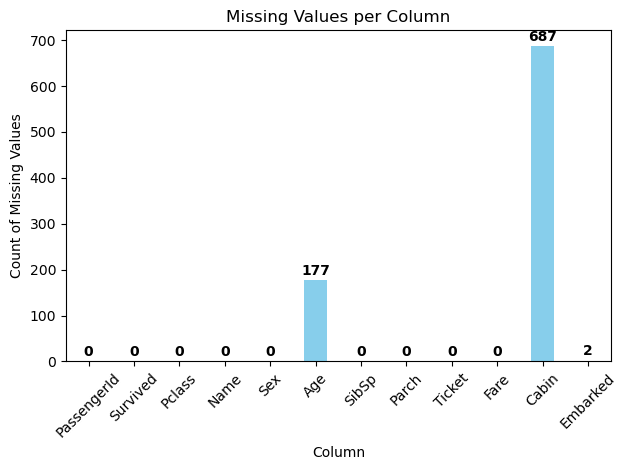

In [10]:
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)

for index, value in enumerate(missing):
    plt.text(index, value+5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

    
plt.tight_layout()
plt.show()


In [11]:
df = df.drop(columns=['Cabin']) 
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [13]:
survival_counts = df['Survived'].value_counts()
print("Survival Counts:\n", survival_counts)


Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\neziy\AppData\Local\Temp\ipykernel_8672\927445151.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


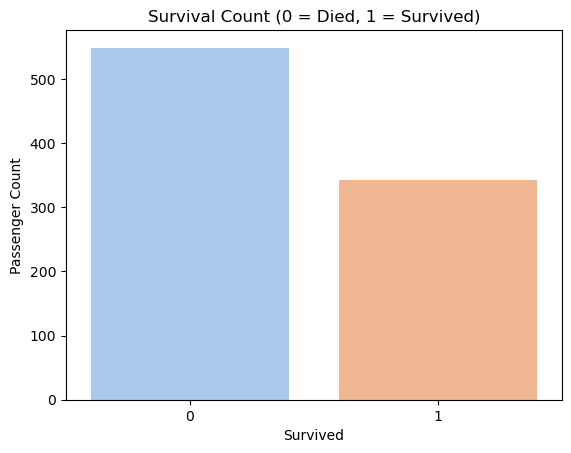

In [14]:
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

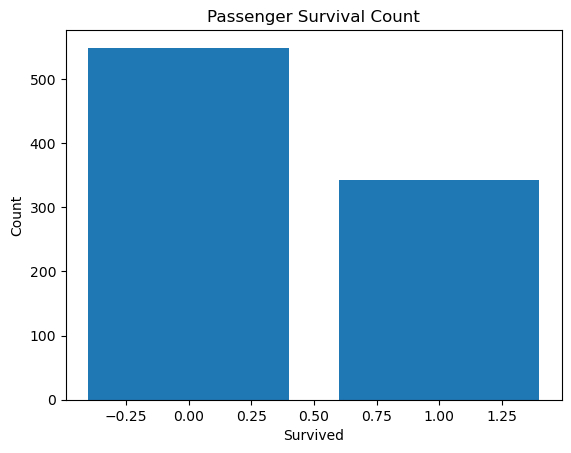

In [15]:
counts = df['Survived'].value_counts() # counts of 0 and 1
plt.bar(counts.index, counts.values)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Passenger Survival Count")
plt.show()

In [16]:
gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [17]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


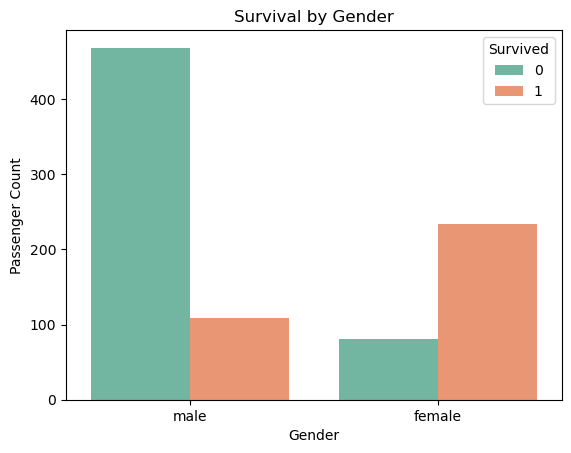

In [18]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [19]:
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [27]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]

y_logistic = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_logistic, test_size=0.2, random_state=42
)


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nLogistic Regression Accuracy:", accuracy)


y_linear = df['Fare']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_linear, test_size=0.2, random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train2, y_train2)

y_pred2 = lin_model.predict(X_test2)

mse = mean_squared_error(y_test2, y_pred2)

print("\nLinear Regression Mean Squared Error:", mse)


Logistic Regression Accuracy: 0.8100558659217877

Linear Regression Mean Squared Error: 6.4097402316860445e-28
